# Bài toán 4: Dự đoán Thời gian Chuyến xe (Trip Duration)

## Mục đích
- Dự đoán thời gian chuyến xe (trip_duration) dựa trên các đặc trưng
- Sử dụng output từ các bài toán trước: `cluster_id`, `rush_hour`
- So sánh nhiều mô hình ML Regressor và chọn mô hình tốt nhất

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
)
from xgboost import XGBRegressor

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load dữ liệu và tái tạo các features từ bài toán trước

In [2]:
# Load raw data
df = pd.read_csv('../data/raw/yellow_tripdata_2016-03.csv')

# Chuyển đổi datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Tính trip_duration (target variable)
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()

# Làm sạch dữ liệu
df = df[(df['pickup_longitude'] != 0) & (df['pickup_latitude'] != 0)]
df = df[(df['dropoff_longitude'] != 0) & (df['dropoff_latitude'] != 0)]
df = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 7200)]  # < 2 giờ
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]
df.dropna(inplace=True)

# Lấy mẫu để đẩy nhanh quá trình
df = df.sample(n=100000, random_state=42).copy()

print(f"✅ Dữ liệu loaded: {df.shape}")
print(f"Trip duration stats:")
print(df['trip_duration'].describe())

✅ Dữ liệu loaded: (100000, 20)
Trip duration stats:
count    100000.000000
mean        820.323360
std         625.858227
min           2.000000
25%         397.000000
50%         656.000000
75%        1052.000000
max        7009.000000
Name: trip_duration, dtype: float64


## 3. Tái tạo cluster_id (từ bài toán 2)

In [3]:
from sklearn.cluster import KMeans

print("Tạo cluster_id bằng KMeans...")
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(df[['pickup_longitude', 'pickup_latitude']])

print(f"✅ Cluster_id created")
print(f"Cluster distribution:\n{df['cluster_id'].value_counts().sort_index()}")

Tạo cluster_id bằng KMeans...
✅ Cluster_id created
Cluster distribution:
cluster_id
0     1719
1    12892
2     2123
3    17016
4        1
5     2792
6    25822
7     6780
8    13548
9    17307
Name: count, dtype: int64


## 4. Sử dụng output của rush_hour (từ bài toán 3)

In [4]:
# Sử dụng output rush_hour từ rush_hour.ipynb (không tái tạo theo rule thời gian)
rush_hour_path = '../data/raw/taxi_cleaned_with_rush_hour.csv'

# Chỉ đọc các cột cần để merge
candidate_cols = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'trip_distance',
    'passenger_count',
    'rush_hour'
]

df_rush = pd.read_csv(rush_hour_path, low_memory=False)
available_cols = [c for c in candidate_cols if c in df_rush.columns]
df_rush = df_rush[available_cols].copy()

# Đồng bộ kiểu datetime để join ổn định
for col in ['tpep_pickup_datetime', 'tpep_dropoff_datetime']:
    if col in df.columns and col in df_rush.columns:
        df[col] = pd.to_datetime(df[col])
        df_rush[col] = pd.to_datetime(df_rush[col])

# Merge theo các khóa chung giữa 2 dataset
merge_keys_preferred = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'trip_distance',
    'passenger_count'
]
merge_keys = [k for k in merge_keys_preferred if k in df.columns and k in df_rush.columns]

if not merge_keys:
    raise ValueError('Không tìm thấy khóa chung để merge rush_hour từ rush_hour.ipynb')

if 'rush_hour' not in df_rush.columns:
    raise ValueError('File output từ rush_hour.ipynb không có cột rush_hour')

before_rows = len(df)
df = df.merge(
    df_rush[merge_keys + ['rush_hour']].drop_duplicates(),
    on=merge_keys,
    how='left'
)

matched_ratio = 1 - df['rush_hour'].isna().mean()
print(f'✅ Đã lấy rush_hour từ {rush_hour_path}')
print(f'Merge keys: {merge_keys}')
print(f'Tỷ lệ match rush_hour: {matched_ratio:.2%}')

# Giữ các dòng có rush_hour hợp lệ từ output trước đó
df = df.dropna(subset=['rush_hour']).copy()
df['rush_hour'] = df['rush_hour'].astype(int)

print(f'Số dòng trước merge: {before_rows:,}')
print(f'Số dòng sau khi giữ rush_hour hợp lệ: {len(df):,}')
print(f'Rush hour distribution:\n{df["rush_hour"].value_counts()}')
print(f'Rush hour ratio: {df["rush_hour"].mean():.2%}')

✅ Đã lấy rush_hour từ ../data/raw/taxi_cleaned_with_rush_hour.csv
Merge keys: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'passenger_count']
Tỷ lệ match rush_hour: 1.65%
Số dòng trước merge: 100,000
Số dòng sau khi giữ rush_hour hợp lệ: 1,649
Rush hour distribution:
rush_hour
0    1174
1     475
Name: count, dtype: int64
Rush hour ratio: 28.81%


## 5. Chuẩn bị Features cho Regressor

In [5]:
# Chọn features để dự đoán trip_duration
# Bao gồm: vị trí, khoảng cách, cluster_id, rush_hour, loại hành khách
feature_cols = [
    'trip_distance',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'cluster_id',
    'rush_hour',
    'passenger_count'
]

# Kiểm tra features có sẵn
available_features = [f for f in feature_cols if f in df.columns]
print(f"Features sử dụng ({len(available_features)}): {available_features}")

X = df[available_features].copy()
y = df['trip_duration'].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature stats:")
print(X.describe())

Features sử dụng (8): ['trip_distance', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'cluster_id', 'rush_hour', 'passenger_count']

X shape: (1649, 8)
y shape: (1649,)

Feature stats:
       trip_distance  pickup_longitude  pickup_latitude  dropoff_longitude  \
count    1649.000000       1649.000000      1649.000000        1649.000000   
mean        2.346016        -73.978509        40.751418         -73.976292   
std         2.151105          0.025486         0.024239           0.026587   
min         0.140000        -74.105278        40.618401         -74.105278   
25%         1.000000        -73.992378        40.736389         -73.991867   
50%         1.640000        -73.982178        40.753181         -73.980530   
75%         2.810000        -73.969170        40.766865         -73.965874   
max        13.340000        -73.776695        40.841007         -73.751205   

       dropoff_latitude   cluster_id    rush_hour  passenger_count  
count    

## 6. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTarget distribution:")
print(f"Train - Mean: {y_train.mean():.2f}s, Std: {y_train.std():.2f}s")
print(f"Test  - Mean: {y_test.mean():.2f}s, Std: {y_test.std():.2f}s")

Training set: (1319, 8)
Test set: (330, 8)

Target distribution:
Train - Mean: 748.52s, Std: 472.09s
Test  - Mean: 737.94s, Std: 442.82s


## 7. Định nghĩa các mô hình Regressor

In [7]:
# Định nghĩa các mô hình với thông tin về scaling requirement
models = {
    'Linear Regression': (LinearRegression(), False),
    'Ridge Regression': (Ridge(alpha=1.0, random_state=42), False),
    'Lasso Regression': (Lasso(alpha=0.1, random_state=42), False),
    'KNN Regressor': (KNeighborsRegressor(n_neighbors=5, n_jobs=-1), True),
    'SVM Regressor': (SVR(kernel='rbf', C=100), True),
    'Random Forest': (RandomForestRegressor(n_estimators=100, max_depth=15, 
                                             random_state=42, n_jobs=-1), False),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                      learning_rate=0.1, random_state=42), False),
    'XGBoost': (XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                             random_state=42, verbosity=0), False)
}

print(f"✅ {len(models)} mô hình đã được định nghĩa")
for name in models.keys():
    print(f"  - {name}")

✅ 8 mô hình đã được định nghĩa
  - Linear Regression
  - Ridge Regression
  - Lasso Regression
  - KNN Regressor
  - SVM Regressor
  - Random Forest
  - Gradient Boosting
  - XGBoost


## 8. Chuẩn bị Scaler (cho các mô hình yêu cầu scaling)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Dữ liệu đã được scaled")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

✅ Dữ liệu đã được scaled
X_train_scaled shape: (1319, 8)
X_test_scaled shape: (330, 8)


## 9. Training và Evaluation Models

In [9]:
results = {}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("="*80)
print("TRAINING VÀ ĐÁNH GIÁ CÁC MÔ HÌNH")
print("="*80)

for name, (model, needs_scaling) in models.items():
    print(f"\n📊 Training {name}...", end=' ', flush=True)
    
    # Chọn dữ liệu scaled hay không
    X_tr = X_train_scaled if needs_scaling else X_train
    X_te = X_test_scaled if needs_scaling else X_test
    
    # Train model
    model.fit(X_tr, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    
    # Metrics on test set
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    mape = mean_absolute_percentage_error(y_test, y_pred_test)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, 
                                  scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cv_scores.mean())
    
    results[name] = {
        'model': model,
        'scaled': needs_scaling,
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2,
        'test_mape': mape,
        'cv_rmse': cv_rmse,
        'cv_rmse_std': np.sqrt(cv_scores.std()),
        'y_pred': y_pred_test
    }
    
    print(f"✅")
    print(f"  RMSE: {rmse:.2f}s | MAE: {mae:.2f}s | R²: {r2:.4f} | MAPE: {mape:.2%}")
    print(f"  CV RMSE: {cv_rmse:.2f}s (±{np.sqrt(cv_scores.std()):.2f}s)")

print("\n" + "="*80)
print("✅ Tất cả mô hình đã được huấn luyện!")
print("="*80)

TRAINING VÀ ĐÁNH GIÁ CÁC MÔ HÌNH

📊 Training Linear Regression... ✅
  RMSE: 294.71s | MAE: 210.48s | R²: 0.5557 | MAPE: 38.60%
  CV RMSE: 311.19s (±82.89s)

📊 Training Ridge Regression... ✅
  RMSE: 294.28s | MAE: 212.37s | R²: 0.5570 | MAPE: 39.33%
  CV RMSE: 313.36s (±74.67s)

📊 Training Lasso Regression... ✅
  RMSE: 293.90s | MAE: 209.96s | R²: 0.5582 | MAPE: 38.58%
  CV RMSE: 311.31s (±79.65s)

📊 Training KNN Regressor... ✅
  RMSE: 306.16s | MAE: 223.13s | R²: 0.5205 | MAPE: 35.69%
  CV RMSE: 326.15s (±98.46s)

📊 Training SVM Regressor... ✅
  RMSE: 282.66s | MAE: 194.20s | R²: 0.5913 | MAPE: 30.29%
  CV RMSE: 299.12s (±73.92s)

📊 Training Random Forest... ✅
  RMSE: 278.66s | MAE: 204.13s | R²: 0.6028 | MAPE: 33.52%
  CV RMSE: 282.04s (±64.25s)

📊 Training Gradient Boosting... ✅
  RMSE: 274.07s | MAE: 198.79s | R²: 0.6158 | MAPE: 32.13%
  CV RMSE: 286.65s (±65.08s)

📊 Training XGBoost... ✅
  RMSE: 283.64s | MAE: 208.47s | R²: 0.5885 | MAPE: 33.51%
  CV RMSE: 284.64s (±61.28s)

✅ Tất 

## 10. So sánh kết quả và chọn mô hình tốt nhất

In [10]:
# Tạo dataframe để so sánh các mô hình
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train RMSE': [results[m]['train_rmse'] for m in results.keys()],
    'Test RMSE': [results[m]['test_rmse'] for m in results.keys()],
    'Test MAE': [results[m]['test_mae'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'Test MAPE': [results[m]['test_mape'] for m in results.keys()],
    'CV RMSE': [results[m]['cv_rmse'] for m in results.keys()],
})

# Sắp xếp theo Test RMSE
comparison_df = comparison_df.sort_values('Test RMSE').reset_index(drop=True)

print("\n📊 BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH")
print("="*120)
print(comparison_df.to_string(index=False))
print("="*120)

# Chọn mô hình tốt nhất (theo Test RMSE)
best_model_name = comparison_df.iloc[0]['Model']
best_test_rmse = comparison_df.iloc[0]['Test RMSE']
best_test_r2 = comparison_df.iloc[0]['Test R²']

print(f"\n🏆 MÔ HÌNH TỐT NHẤT: {best_model_name}")
print(f"  Test RMSE: {best_test_rmse:.2f}s")
print(f"  Test R²: {best_test_r2:.4f}")


📊 BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH
            Model  Train RMSE  Test RMSE   Test MAE  Test R²  Test MAPE    CV RMSE
Gradient Boosting  132.109357 274.073887 198.794450 0.615771   0.321344 286.647530
    Random Forest  108.046654 278.656426 204.134693 0.602815   0.335226 282.041046
    SVM Regressor  281.855685 282.664079 194.199714 0.591308   0.302908 299.119912
          XGBoost  101.336230 283.641722 208.466404 0.588476   0.335086 284.639234
 Lasso Regression  306.666551 293.896073 209.957258 0.558183   0.385815 311.306047
 Ridge Regression  309.931798 294.275199 212.370198 0.557042   0.393293 313.356279
Linear Regression  306.485763 294.709130 210.476620 0.555735   0.386029 311.185974
    KNN Regressor  257.179604 306.164392 223.129091 0.520526   0.356937 326.146374

🏆 MÔ HÌNH TỐT NHẤT: Gradient Boosting
  Test RMSE: 274.07s
  Test R²: 0.6158


## 11. Visualize Model Performance

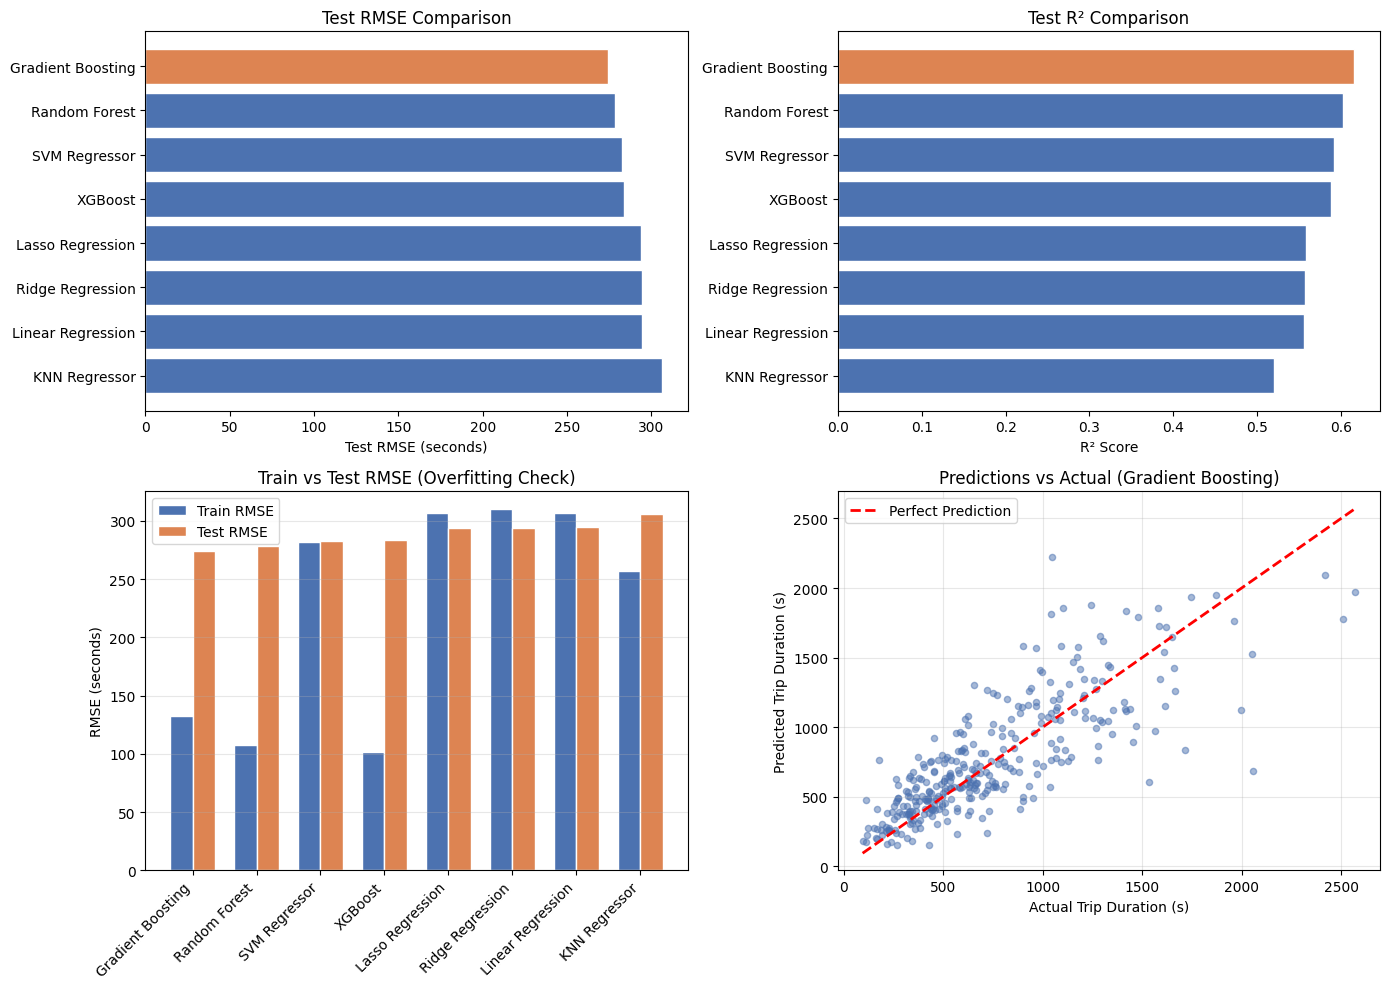

✅ Visualization saved as 'trip_duration_model_comparison.png'


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Test RMSE comparison
comparison_sorted = comparison_df.sort_values('Test RMSE')
colors = ['#DD8452' if m == best_model_name else '#4C72B0' for m in comparison_sorted['Model']]
axes[0, 0].barh(comparison_sorted['Model'], comparison_sorted['Test RMSE'], color=colors, edgecolor='white')
axes[0, 0].set_xlabel('Test RMSE (seconds)')
axes[0, 0].set_title('Test RMSE Comparison')
axes[0, 0].invert_yaxis()

# Plot 2: Test R² comparison
comparison_sorted_r2 = comparison_df.sort_values('Test R²', ascending=False)
colors = ['#DD8452' if m == best_model_name else '#4C72B0' for m in comparison_sorted_r2['Model']]
axes[0, 1].barh(comparison_sorted_r2['Model'], comparison_sorted_r2['Test R²'], color=colors, edgecolor='white')
axes[0, 1].set_xlabel('R² Score')
axes[0, 1].set_title('Test R² Comparison')
axes[0, 1].invert_yaxis()

# Plot 3: Train vs Test RMSE (overfitting check)
models_to_plot = comparison_df['Model']
x = np.arange(len(models_to_plot))
width = 0.35

axes[1, 0].bar(x - width/2, comparison_df['Train RMSE'], width, label='Train RMSE', color='#4C72B0', edgecolor='white')
axes[1, 0].bar(x + width/2, comparison_df['Test RMSE'], width, label='Test RMSE', color='#DD8452', edgecolor='white')
axes[1, 0].set_ylabel('RMSE (seconds)')
axes[1, 0].set_title('Train vs Test RMSE (Overfitting Check)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models_to_plot, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Predictions vs Actual (Best Model)
best_model_results = results[best_model_name]
y_pred_best = best_model_results['y_pred']

# Plot first 500 predictions for clarity
n_sample = min(500, len(y_test))
axes[1, 1].scatter(y_test.iloc[:n_sample], y_pred_best[:n_sample], alpha=0.5, s=20, color='#4C72B0')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Trip Duration (s)')
axes[1, 1].set_ylabel('Predicted Trip Duration (s)')
axes[1, 1].set_title(f'Predictions vs Actual ({best_model_name})')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trip_duration_model_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

print("✅ Visualization saved as 'trip_duration_model_comparison.png'")

## 12. Dự đoán Trip Duration cho toàn bộ Dataset

In [12]:
print(f"Dùng mô hình {best_model_name} để dự đoán toàn bộ dataset...")

best_model = results[best_model_name]['model']
best_model_needs_scaling = results[best_model_name]['scaled']

# Prepare full data
X_full = df[available_features].copy()
if best_model_needs_scaling:
    X_full_scaled = scaler.transform(X_full)
    y_pred_full = best_model.predict(X_full_scaled)
else:
    y_pred_full = best_model.predict(X_full)

# Thêm cột prediction vào dataframe
df['predicted_trip_duration'] = y_pred_full

print(f"✅ Dự đoán hoàn tất!")
print(f"\nPredicted trip_duration statistics:")
print(df['predicted_trip_duration'].describe())
print(f"\nActual vs Predicted:")
print(f"  Actual mean: {df['trip_duration'].mean():.2f}s")
print(f"  Predicted mean: {df['predicted_trip_duration'].mean():.2f}s")
print(f"\nSample predictions:")
sample_df = df[['trip_distance', 'rush_hour', 'cluster_id', 'trip_duration', 'predicted_trip_duration']].head(10)
print(sample_df)

Dùng mô hình Gradient Boosting để dự đoán toàn bộ dataset...
✅ Dự đoán hoàn tất!

Predicted trip_duration statistics:
count    1649.000000
mean      752.037868
std       421.652455
min       102.517884
25%       447.821976
50%       629.798870
75%       987.129912
max      2494.943431
Name: predicted_trip_duration, dtype: float64

Actual vs Predicted:
  Actual mean: 746.41s
  Predicted mean: 752.04s

Sample predictions:
     trip_distance  rush_hour  cluster_id  trip_duration  \
26            1.64          1           3          613.0   
69            2.80          0           6          880.0   
95            4.90          0           8         1924.0   
113           1.00          1           6          404.0   
188           1.70          0           6          525.0   
194           1.20          0           9          363.0   
199           0.79          0           9          590.0   
221           0.34          0           7          211.0   
234           1.64          0       

## 13. Lưu kết quả

In [13]:
# Lưu dataframe với predictions
output_path = '../data/raw/taxi_with_predictions.csv'

# Chọn columns để lưu
save_cols = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'trip_distance', 'passenger_count',
    'trip_duration', 'predicted_trip_duration',
    'cluster_id', 'rush_hour'
]

save_cols = [c for c in save_cols if c in df.columns]
df_export = df[save_cols].copy()

df_export.to_csv(output_path, index=False)
print(f"✅ Kết quả lưu vào: {output_path}")
print(f"   Số dòng: {len(df_export)}")
print(f"   Số cột: {len(df_export.columns)}")

# Lưu model evaluation report
report_path = '../data/raw/trip_duration_model_report.txt'
with open(report_path, 'w') as f:
    f.write("=" * 100 + "\n")
    f.write("TRIP DURATION PREDICTION - MODEL EVALUATION REPORT\n")
    f.write("=" * 100 + "\n\n")
    
    f.write(f"BEST MODEL: {best_model_name}\n")
    f.write(f"-" * 100 + "\n")
    f.write(f"Test RMSE: {best_test_rmse:.2f} seconds\n")
    f.write(f"Test MAE: {results[best_model_name]['test_mae']:.2f} seconds\n")
    f.write(f"Test R²: {best_test_r2:.4f}\n")
    f.write(f"Test MAPE: {results[best_model_name]['test_mape']:.2%}\n")
    f.write(f"\n")
    
    f.write("\nALL MODELS COMPARISON:\n")
    f.write("-" * 100 + "\n")
    f.write(comparison_df.to_string(index=False))
    f.write("\n")

print(f"✅ Report lưu vào: {report_path}")

✅ Kết quả lưu vào: ../data/raw/taxi_with_predictions.csv
   Số dòng: 1649
   Số cột: 12
✅ Report lưu vào: ../data/raw/trip_duration_model_report.txt


## 14. Tóm tắt kết quả

In [14]:
print("\n" + "="*100)
print("📋 TÓM TẮT KẾT QUẢ - DỰ ĐOÁN TRIP DURATION")
print("="*100)

print(f"\n✅ BƯỚC 1: DATA PREPARATION")
print(f"   - Loaded data: {len(df)} records")
print(f"   - Created cluster_id: {df['cluster_id'].nunique()} clusters")
print(f"   - Created rush_hour label")
print(f"   - Target variable (trip_duration): {df['trip_duration'].min():.0f}s - {df['trip_duration'].max():.0f}s")

print(f"\n✅ BƯỚC 2: FEATURE ENGINEERING")
print(f"   - Total features used: {len(available_features)}")
print(f"   - Features: {', '.join(available_features)}")

print(f"\n✅ BƯỚC 3: MODEL TRAINING & COMPARISON")
print(f"   - Total models trained: {len(models)}")
print(f"   - Train/Test split: 80/20")
print(f"   - Cross-validation: 5-Fold")

print(f"\n✅ BƯỚC 4: MODEL SELECTION")
print(f"   🏆 BEST MODEL: {best_model_name}")
print(f"      - Test RMSE: {best_test_rmse:.2f} seconds")
print(f"      - Test MAE: {results[best_model_name]['test_mae']:.2f} seconds")
print(f"      - Test R²: {best_test_r2:.4f}")
print(f"      - CV RMSE: {results[best_model_name]['cv_rmse']:.2f}s (±{results[best_model_name]['cv_rmse_std']:.2f}s)")

print(f"\n✅ BƯỚC 5: PREDICTIONS")
print(f"   - Predicted trip_duration for all {len(df)} records")
print(f"   - Prediction range: {df['predicted_trip_duration'].min():.0f}s - {df['predicted_trip_duration'].max():.0f}s")
print(f"   - Mean prediction: {df['predicted_trip_duration'].mean():.2f}s")

print(f"\n✅ BƯỚC 6: OUTPUT FILES")
print(f"   - Data with predictions: {output_path}")
print(f"   - Model evaluation report: {report_path}")
print(f"   - Visualization: trip_duration_model_comparison.png")

print("\n" + "="*100)
print("✅ Hoàn tất bài toán dự đoán Trip Duration!")
print("="*100)


📋 TÓM TẮT KẾT QUẢ - DỰ ĐOÁN TRIP DURATION

✅ BƯỚC 1: DATA PREPARATION
   - Loaded data: 1649 records
   - Created cluster_id: 9 clusters
   - Created rush_hour label
   - Target variable (trip_duration): 83s - 2619s

✅ BƯỚC 2: FEATURE ENGINEERING
   - Total features used: 8
   - Features: trip_distance, pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude, cluster_id, rush_hour, passenger_count

✅ BƯỚC 3: MODEL TRAINING & COMPARISON
   - Total models trained: 8
   - Train/Test split: 80/20
   - Cross-validation: 5-Fold

✅ BƯỚC 4: MODEL SELECTION
   🏆 BEST MODEL: Gradient Boosting
      - Test RMSE: 274.07 seconds
      - Test MAE: 198.79 seconds
      - Test R²: 0.6158
      - CV RMSE: 286.65s (±65.08s)

✅ BƯỚC 5: PREDICTIONS
   - Predicted trip_duration for all 1649 records
   - Prediction range: 103s - 2495s
   - Mean prediction: 752.04s

✅ BƯỚC 6: OUTPUT FILES
   - Data with predictions: ../data/raw/taxi_with_predictions.csv
   - Model evaluation report: ../data/r